# Layer Skipping Analysis on DINO

This notebook analyzes information flow between layers in a transformer model (e.g., DINO ViT) to identify redundant layers that can potentially be skipped without significantly affecting classification performance. The analysis includes similarity comparisons between layer representations (using CKA, CKNNA, cosine similarity) and a linear probing experiment to test the impact of removing selected layers.

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import Subset, DataLoader

from PIL import Image
import timm
import os
import sys
import random

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

c:\Users\olenk\PWProjects\WB_2_Project\VisualLogitLens\dino_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reproducibility
To ensure consistent results across runs, we fix all random seeds. This guarantees that data sampling and model behavior are deterministic and reproducible.

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### Load and Filter ImageNet Subset

We load a subset of the ImageNet dataset from local folders and select images belonging to a single class. Images are transformed to match the input requirements of DINO models.

In [3]:
train_path = "../data/train.X1"
val_path = "../data/val.X"

transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

classes = train_dataset.classes  

selected_class = classes[0]
print("Selected class:", selected_class)

class_idx = train_dataset.class_to_idx[selected_class]

def get_class_subset(dataset, class_idx):
    indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
    return Subset(dataset, indices)

train_subset = get_class_subset(train_dataset, class_idx)
val_subset = get_class_subset(val_dataset, class_idx)

train_loader = DataLoader(train_subset, batch_size=8, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False)

Selected class: n01440764


In [21]:
def extract_layer_outputs(model, x):
    '''
    Extracts intermediate layer outputs from a ViT model during a forward pass.
    '''
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = [blk.register_forward_hook(hook_fn) for blk in model.blocks]

    with torch.no_grad():
        _ = model(x)

    for hook in hooks:
        hook.remove()

    return activations


def compute_logits_from_layers(model, layer_outputs):
    '''
    Computes classification logits from intermediate layer representations using the model's head.
    '''
    cls_tokens = [output[:, 0] for output in layer_outputs]  # CLS token
    norm = model.norm
    head = model.head
    logits = [head(norm(cls)) for cls in cls_tokens]
    return logits


def collect_logits_from_batches(model, dataloader, max_batches=None):
    '''
    Collects logits from all transformer layers for multiple batches of data.
    '''
    all_logits = []

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_batch = x_batch.to(next(model.parameters()).device)
        layer_outputs = extract_layer_outputs(model, x_batch)
        logits = compute_logits_from_layers(model, layer_outputs)
        all_logits.append(logits)

    return all_logits

### Similarity Metrics Between Layer Representations
To investigate the flow and redundancy of information across layers in the ViT model, we apply the following similarity measures between layer-wise representations:

1. Cosine Similarity Matrix

Cosine similarity measures the angle between two vectors, indicating their directional alignment regardless of magnitude. For each pair of layers, we compute cosine similarity between their logits (normalized [CLS] tokens passed through the model head), averaged across the batch:

$$\text{similarity}(x, y) = \frac{x \cdot y}{||x|| \cdot ||y||}$$
 
Interpretation:

* Values close to 1 indicate highly similar representations.
* Values around 0 suggest orthogonality (no similarity).
* Values below 0 (rare but possible) indicate opposing directions in feature space.

In [22]:
def compute_cosine_similarity_matrix(logits):
    """
    Fully vectorized computation of cosine similarity matrix between L layer outputs.
    Uses F.cosine_similarity and removes nested loops.
    """
    x = torch.stack([F.normalize(t.detach(), dim=-1) for t in logits])

    x1 = x[:, None, :, :] 
    x2 = x[None, :, :, :]

    cos = F.cosine_similarity(x1, x2, dim=-1)

    sim_matrix = cos.mean(dim=-1)

    return sim_matrix.cpu().numpy()

2. Linear CKA (Centered Kernel Alignment)

Centered Kernel Alignment (CKA) is a similarity metric used to compare the internal representations of neural networks. It is especially useful for analyzing and comparing the learned representations between layers, models, or across training checkpoints.

Unlike simpler similarity metrics like cosine similarity, CKA is invariant to orthogonal transformations and isotropic scaling of representations. This makes it a more robust and reliable measure when working with high-dimensional embeddings such as those produced by vision transformers (ViTs).

CKA quantifies how similarly two sets of features (e.g., from different layers of a model) encode information. A high CKA value (close to 1) indicates that both layers capture very similar patterns in the data, even if the actual vector values differ due to rotation or scaling.

#### Interpretation:

* Values range from 0 (no similarity) to 1 (perfect similarity).
* High values suggest that two layers encode similar information.

#### Implementation
In this project, we use the linear CKA variant based on the implementation from the following GitHub repository:

[yuanli2333/CKA-Centered-Kernel-Alignment](https://github.com/yuanli2333/CKA-Centered-Kernel-Alignment/tree/master)

In [23]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from metrics.CKA import linear_CKA

In [24]:
def compute_cka_matrix(logits):
    L = len(logits)
    matrix = torch.zeros(L, L)
    logits = [F.normalize(logit.detach(), dim=-1) for logit in logits]

    for i in range(L):
        for j in range(i, L):
            val = linear_CKA(logits[i], logits[j])
            matrix[i, j] = val
            matrix[j, i] = val

    return matrix.numpy()

3. Centered Kernel Normalized Nearest Neighbors Agreement (CKNNA)

CKNNA is a similarity metric designed to evaluate the consistency of local neighborhoods between different layers' representations in a neural network.

CKA (Centered Kernel Alignment) is a global similarity measure that compares two feature spaces via centered kernels, effectively capturing overall alignment between them. CKNNA, in contrast, focuses on local structure by aligning the nearest neighbors in each representation.
It modifies CKA by:
* Applying a top-k nearest neighbor mask before computing similarity,
* Emphasizing local geometry preservation across feature spaces.

According to [The Platonic Representation Hypothesis](https://arxiv.org/abs/2405.07987) those are recommended parameters:
* topk = 10

#### Interpretation:
* Values close to **1** indicate that the neighborhood structure is preserved between the two layers in kernel space.
* Values close to **0** indicate dissimilar neighborhood structures, suggesting information drift or change in local geometry.

#### Implementation
In this project, we use the linear CKA variant based on the implementation from the following GitHub repository:

[CKNNA GitHub Repository](https://github.com/minyoungg/platonic-rep/tree/main)

In [25]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from metrics.CKNNA import AlignmentMetrics

In [26]:
def compute_cknna_matrix(logits, k=10):
    L = len(logits)
    matrix = np.zeros((L, L))
    
    for i in range(L):
        for j in range(i, L):
            sim = AlignmentMetrics.cknna(logits[i], logits[j], topk=k)
            matrix[i, j] = sim
            matrix[j, i] = sim
    
    return matrix

In [27]:
def plot_similarity_matrix(matrix, title="Similarity Matrix", vmin=-1.0, vmax=1.0):
    mask = np.tril(np.ones_like(matrix, dtype=bool), k=-1)
    rounded_matrix = np.round(matrix, 2)

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        rounded_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        vmin=vmin,
        vmax=vmax,
        cmap="Spectral_r",
        cbar=True,
    )

    plt.title(title)
    plt.xlabel("Layer")
    plt.ylabel("Layer")
    plt.show()


### Data Flow & Dimension Explanation

In [ ]:
def extract_layer_outputs_printable(model, x):
    '''
    Extracts intermediate layer outputs from a ViT model during a forward pass.
    '''
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = [blk.register_forward_hook(hook_fn) for blk in model.blocks]

    with torch.no_grad():
        _ = model(x)

    for hook in hooks:
        hook.remove()

    print(f"[extract_layer_outputs] Total layers: {len(activations)}")
    for i, act in enumerate(activations):
        print(f"  Layer {i}: activation shape = {act.shape}")

    return activations


def compute_logits_from_layers_printable(model, layer_outputs):
    '''
    Computes classification logits from intermediate layer representations using the model's head.
    '''
    cls_tokens = [output[:, 0] for output in layer_outputs]
    print(f"[compute_logits_from_layers] CLS tokens shapes:")
    for i, cls in enumerate(cls_tokens):
        print(f"  Layer {i}: cls shape: {cls.shape}")

    norm = model.norm
    head = model.head
    logits = [head(norm(cls)) for cls in cls_tokens]

    print(f"[compute_logits_from_layers] Logits shapes:")
    for i, logit in enumerate(logits):
        print(f"  Layer {i} logit shape: {logit.shape}")

    return logits


def collect_logits_from_batches_printable(model, dataloader, max_batches=None):
    '''
    Collects logits from all transformer layers for multiple batches of data.
    '''
    all_logits = []

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        print(f"\n[collect_logits_from_batches] Batch {batch_idx}")
        x_batch = x_batch.to(next(model.parameters()).device)
        print(f"  Input batch shape: {x_batch.shape}")

        layer_outputs = extract_layer_outputs_printable(model, x_batch)
        logits = compute_logits_from_layers_printable(model, layer_outputs)

        print(f"  Collected logits for batch {batch_idx}: {len(logits)} layers")
        print(f"    Example shape (layer 0): {logits[0].shape}")

        all_logits.append(logits)

    print(f"\n[collect_logits_from_batches] Total batches processed: {len(all_logits)}")
    print(f"  Shape of all_logits[0][0]: {all_logits[0][0].shape}")

    return all_logits

In [32]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model.eval()
all_logits = collect_logits_from_batches_printable(model, train_loader, max_batches=2)

num_layers = len(all_logits[0])
combined_logits = []
for i in range(num_layers):
    layer_logits = [batch[i] for batch in all_logits]
    combined = torch.cat(layer_logits, dim=0)
    combined_logits.append(combined)

Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main



[collect_logits_from_batches] Batch 0
  Input batch shape: torch.Size([8, 3, 224, 224])
[extract_layer_outputs] Total layers: 12
  Layer 0: activation shape = torch.Size([8, 197, 384])
  Layer 1: activation shape = torch.Size([8, 197, 384])
  Layer 2: activation shape = torch.Size([8, 197, 384])
  Layer 3: activation shape = torch.Size([8, 197, 384])
  Layer 4: activation shape = torch.Size([8, 197, 384])
  Layer 5: activation shape = torch.Size([8, 197, 384])
  Layer 6: activation shape = torch.Size([8, 197, 384])
  Layer 7: activation shape = torch.Size([8, 197, 384])
  Layer 8: activation shape = torch.Size([8, 197, 384])
  Layer 9: activation shape = torch.Size([8, 197, 384])
  Layer 10: activation shape = torch.Size([8, 197, 384])
  Layer 11: activation shape = torch.Size([8, 197, 384])
[compute_logits_from_layers] CLS tokens shapes:
  Layer 0: cls shape: torch.Size([8, 384])
  Layer 1: cls shape: torch.Size([8, 384])
  Layer 2: cls shape: torch.Size([8, 384])
  Layer 3: cls shap

#### From Input to all_logits (shape and flow)

1. --------- Input Batch from the DataLoader ---------
```python
for batch_idx, (x_batch, _) in enumerate(dataloader):
```

Input batch shape: x_batch.shape == torch.Size([8, 3, 224, 224]) (batch_size = 8) -> (8 RGB images, 224×224 resolution)

2. --------- extract_layer_outputs(model, x_batch) ---------

* Hooks are registered for all transformer blocks, after forward pass, each layer output is captured
* Activation shape: activation.shape == torch.Size([8, 197, 384]) -> [batch_size, num_tokens, embedding_dim] (197 = 1 [CLS] token + 196 patch tokens) 

layer_outputs = List of 12 tensors, each of shape [8, 197, 384]

3. --------- compute_logits_from_layers(model, layer_outputs) ---------
```python
cls_tokens = [output[:, 0] for output in layer_outputs]
logits = [head(norm(cls)) for cls in cls_tokens]
return logits
```
* output[:, 0] selects the [CLS] token for each image in the batch
* norm(cls) applies layer normalization
* head(...) applies the classification head (e.g. a linear layer)
* Logit Shape: logit.shape == torch.Size([8, 384]) -> [batch_size, embedding_dim]

logits = List of 12 tensors, each of shape [8, 384]

4. --------- collect_logits_from_batches(...) ---------

```python
all_logits.append(logits)
```
Final all_logits structure:

```python
all_logits: List of B batches
  each element = List of L layers
    each layer = Tensor [batch_size, 384]
```

5. --------- Combining Batches per Layer ---------

combined_logits = List of 12 tensors, each of shape [total_images, 384]


### Layer-to-Layer Similarity Analysis

In [30]:
models = {
    "DINO ViT-S/16": torch.hub.load('facebookresearch/dino:main', 'dino_vits16'),
    "DINO ViT-B/8": torch.hub.load('facebookresearch/dino:main', 'dino_vitb8'),
}

Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main
Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main



----- DINO ViT-S/16 -----


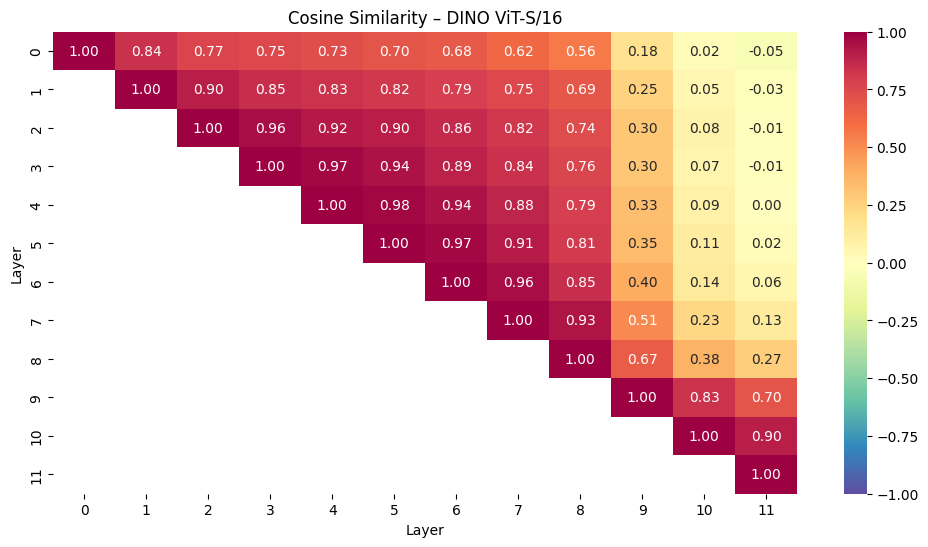

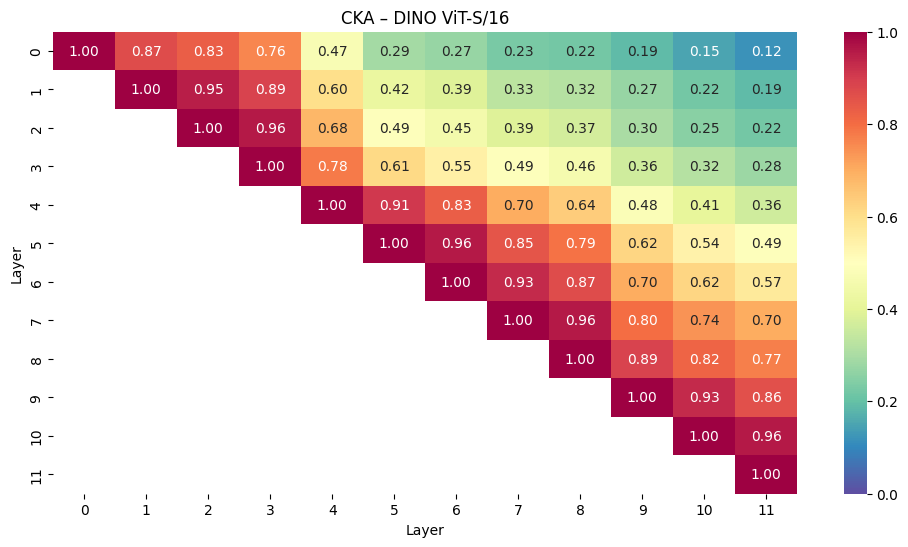

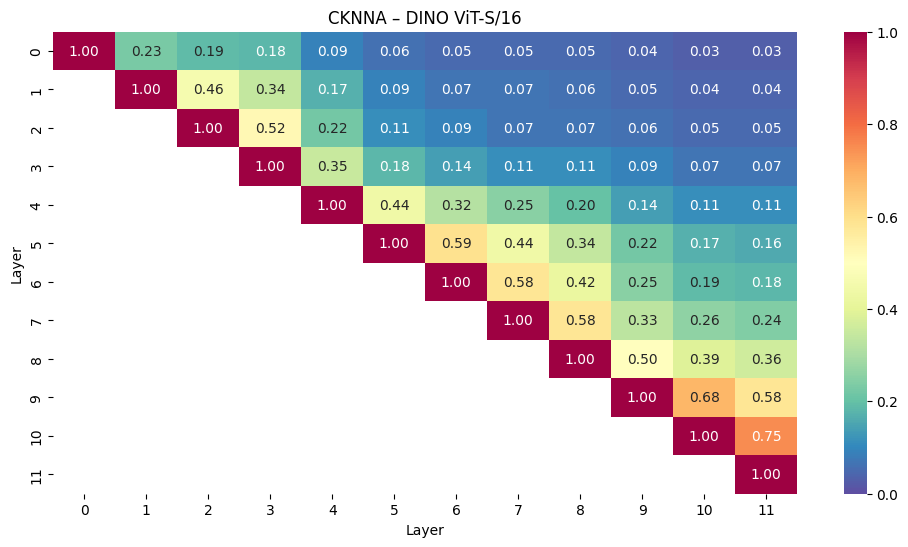


----- DINO ViT-B/8 -----


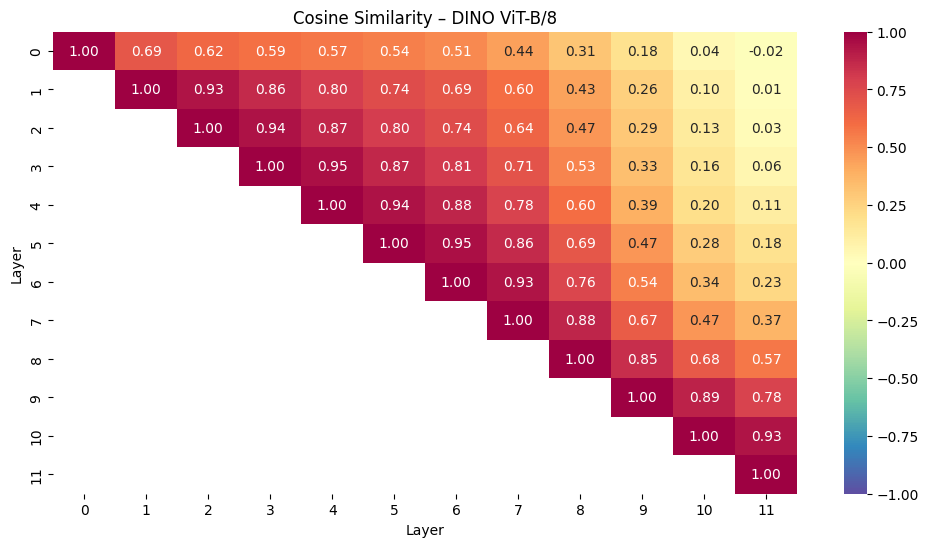

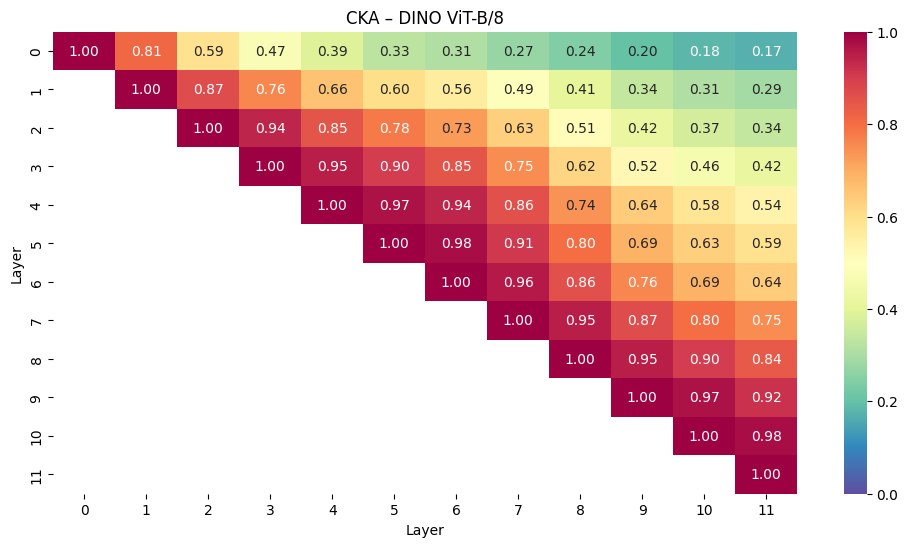

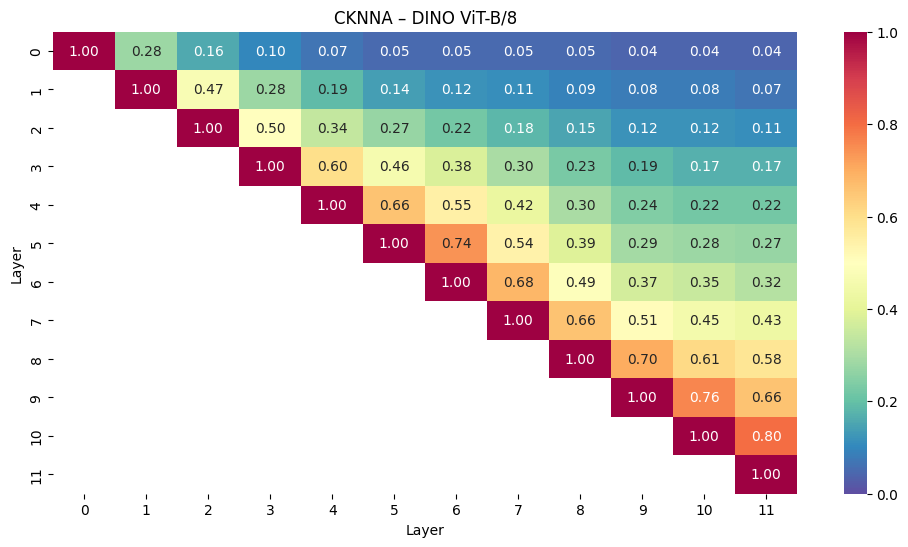

In [31]:
for model in models.values():
    model.eval()

for model_name, model in models.items():
    print(f"\n----- {model_name} -----")
    
    all_logits = collect_logits_from_batches(model, train_loader, max_batches=None)
    num_layers = len(all_logits[0])
    combined_logits = []

    for i in range(num_layers):
        layer_logits = [batch[i] for batch in all_logits]
        combined = torch.cat(layer_logits, dim=0)
        combined_logits.append(combined)

    cos_matrix = compute_cosine_similarity_matrix(combined_logits)
    cka_matrix = compute_cka_matrix(combined_logits)
    cknna_matrix = compute_cknna_matrix(combined_logits)

    plot_similarity_matrix(cos_matrix, title=f"Cosine Similarity – {model_name}")
    plot_similarity_matrix(cka_matrix, title=f"CKA – {model_name}", vmin=0)
    plot_similarity_matrix(cknna_matrix, title=f"CKNNA – {model_name}", vmin=0)

#### Layer Redundancy Analysis – DINO ViT-S/16

To identify redundant layers within the DINO ViT-S/16 transformer, we analyzed three similarity metrics computed between logits extracted at different transformer blocks: Cosine Similarity, Centered Kernel Alignment (CKA), and CKNNA. Each metric captures different aspects of representational similarity and redundancy.

***Cosine Similarity*** reveals consistently high similarity between intermediate layers, particularly in the range of **layers 2 to 6**. This suggests that these layers produce embeddings with similar directional structure, indicating possible functional redundancy.

***CKA***, which is sensitive to linear transformations and alignment of subspaces, further highlights high similarity in several consecutive layer pairs:

* Layer 2 ↔ 3
* Layer 5 ↔ 6
* Layer 7 ↔ 8
* Layer 10 ↔ 11

This pattern implies that some of these layers may be learning overlapping information.

***CKNNA***, which assesses local neighborhood agreement in embedding space, shows the strongest redundancy between **layers 10 and 11**, reinforcing the CKA result for this pair.

#### Conclusion 

Based on the combined insights from all three similarity measures, the following layers appear to be potential candidates for removal or skipping during inference or fine-tuning:

* Layer 3 (high similarity with layer 2)
* Layer 6 (high similarity with layer 5)
* Layer 8 (high similarity with layer 7)
* Layer 11 (high similarity with layer 10 across both CKA and CKNNA)

#### Layer Redundancy Analysis – DINO ViT-B/8

To assess representational redundancy within the DINO ViT-B/8 model, we examined pairwise similarity between layer-wise logits using three complementary metrics: Cosine Similarity, Centered Kernel Alignment (CKA), and CKNNA. These metrics collectively offer insight into both the geometric and relational similarity of representations across the network.

***Cosine Similarity*** indicates strong alignment among the early and middle layers, particularly across **layers 1 to 7**. This suggests that many of these layers produce directionally similar representations, potentially pointing to overlapping functional roles.

***CKA*** provides a deeper view into the subspace-level similarity of representations. It reveals notably high similarity across:

* Layer 4 ↔ 5
* Layer 5 ↔ 6
* Layer 9 ↔ 10
* Layer 10 ↔ 11

These clusters of similarity suggest that these layers may be learning nearly redundant features.

CKNNA, which measures local neighborhood consistency and is particularly sensitive to structural redundancy in learned embeddings, confirms the CKA findings. It highlights the layer pairs **5–6 and 10–11** as having the highest representational overlap.

#### Conclusion
Based on this multi-metric analysis, several layers emerge as candidates for removal or bypassing in a model compression or acceleration scenario:

Layer 5 or 6 (redundant per CKA and CKNNA)

Layer 10 or 11 (high similarity in both CKA and CKNNA)